In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from pygam import LinearGAM, s, te

# transformer package (pytorch)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
# importing and browsing data
csv_path = Path("..") / "Dataset" / "Outputs" / "CS2_model_input.csv"
df = pd.read_csv(csv_path)

print("Path:", csv_path.resolve())
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
display(df.head(5))

Path: D:\Waterloo\terms\MDSAI\1B\stat946\Data-Science-Case-Study-1\Dataset\Outputs\CS2_model_input.csv
Shape: (70128, 24)

Columns: ['Zone', 'PM25', 'Datetime_UTC', 'fire_count_regional', 'frp_regional_sum', 'hfi_weighted', 'fwi_mean', 'fire_count_local', 'frp_local_sum', 'PM25_lag_1h', 'PM25_lag_6h', 'PM25_lag_24h', 'PM25_lag_48h', 'PM25_roll_24h_mean', 'PM25_roll_24h_max', 'PM25_roll_7d_mean', 'frp_roll_24h_sum', 'frp_roll_72h_sum', 'hour', 'day_of_week', 'month', 'is_wildfire_season', 'season', 'alert']

Dtypes:
 Zone                    object
PM25                   float64
Datetime_UTC            object
fire_count_regional    float64
frp_regional_sum       float64
hfi_weighted           float64
fwi_mean               float64
fire_count_local       float64
frp_local_sum          float64
PM25_lag_1h            float64
PM25_lag_6h            float64
PM25_lag_24h           float64
PM25_lag_48h           float64
PM25_roll_24h_mean     float64
PM25_roll_24h_max      float64
PM25_roll_7d_

,Zone,PM25,Datetime_UTC,fire_count_regional,frp_regional_sum,hfi_weighted,fwi_mean,fire_count_local,frp_local_sum,PM25_lag_1h,...,PM25_roll_24h_max,PM25_roll_7d_mean,frp_roll_24h_sum,frp_roll_72h_sum,hour,day_of_week,month,is_wildfire_season,season,alert
0,Lower Fraser Valley,6.351373,2022-01-01 09:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,6.351373,6.351373,0.0,0.0,9,5,1,0,Winter,0
1,Lower Fraser Valley,6.299942,2022-01-01 10:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,6.351373,...,6.351373,6.325658,0.0,0.0,10,5,1,0,Winter,0
2,Lower Fraser Valley,5.474733,2022-01-01 11:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,6.299942,...,6.351373,6.042016,0.0,0.0,11,5,1,0,Winter,0
3,Lower Fraser Valley,4.187194,2022-01-01 12:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,5.474733,...,6.351373,5.578310,0.0,0.0,12,5,1,0,Winter,0
4,Lower Fraser Valley,3.418764,2022-01-01 13:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,4.187194,...,6.351373,5.146401,0.0,0.0,13,5,1,0,Winter,0


In [4]:
# check wildfire related data
wildfire_cols = [
    "fire_count_regional",
    "frp_regional_sum",
    "hfi_weighted",
    "fwi_mean",
    "fire_count_local",
    "frp_local_sum",
]
for c in wildfire_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# counts + percents of non-zero (treat NaN as zero for the non-zero test)
nonzero_counts = df.groupby("Zone")[wildfire_cols].apply(lambda g: (g.fillna(0) != 0).sum())
row_counts = df.groupby("Zone").size().rename("n_rows")

nonzero_pct = (nonzero_counts.div(row_counts, axis=0) * 100).round(2)
nonzero_pct.columns = [f"{c}_pct" for c in nonzero_pct.columns]

summary = pd.concat([row_counts, nonzero_counts, nonzero_pct], axis=1).sort_index()

display(summary)

,n_rows,fire_count_regional,frp_regional_sum,hfi_weighted,fwi_mean,fire_count_local,frp_local_sum,fire_count_regional_pct,frp_regional_sum_pct,hfi_weighted_pct,fwi_mean_pct,fire_count_local_pct,frp_local_sum_pct
Zone,,,,,,,,,,,,,
Lower Fraser Valley,35064,4859,4857,4005,4765,1007,1007,13.86,13.85,11.42,13.59,2.87,2.87
Southern Interior,35064,6770,6751,5781,6610,3526,3526,19.31,19.25,16.49,18.85,10.06,10.06


## Baseline model
- no feature engineering, just using the raw data
- 2 baselines:
    - base features
    - base features + wildfire features

In [5]:
# Baseline Modeling Preparation
WILDFIRE_COLS = [
    "fire_count_regional",
    "frp_regional_sum",
    "hfi_weighted",
    "fwi_mean",
    "fire_count_local",
    "frp_local_sum",
]

BASE_COLS = [
    "PM25_lag_24h",
    "PM25_lag_48h",
    "lag3",          # we will create this
    "hour",
    "day_of_week",
    "month",
]

ENHANCED_COLS = BASE_COLS + WILDFIRE_COLS

def make_zone_table(df_zone: pd.DataFrame) -> pd.DataFrame:
    d = df_zone.copy()
    # ✅ force datetime
    d["Datetime_UTC"] = pd.to_datetime(d["Datetime_UTC"], utc=True, errors="coerce")

    d = d.sort_values("Datetime_UTC")
    d["PM25"] = pd.to_numeric(d["PM25"], errors="coerce")

    # create lag3 from PM25 (3 hours back within zone)
    d["lag3"] = d["PM25"].shift(3)

    # ensure numeric wildfire cols
    for c in WILDFIRE_COLS:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    # calendar cols should already exist, but ensure numeric
    for c in ["hour", "day_of_week", "month"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    # drop rows with missing in any needed columns later (done after selecting features)
    return d

def fit_gam_and_eval(
    d: pd.DataFrame,
    feature_cols: list[str],
    train_years=(2022, 2023, 2024),
    test_year=2025,
    threshold=25.0,
):
    # select rows for train/test
    d = d.copy()
    d["year"] = d["Datetime_UTC"].dt.year

    # drop NA for selected features + target
    d_model = d.dropna(subset=feature_cols + ["PM25"]).copy()

    train = d_model[d_model["year"].isin(train_years)]
    test = d_model[d_model["year"].eq(test_year)]

    if len(train) < 500 or len(test) < 100:
        raise ValueError(f"Too few rows: train={len(train)}, test={len(test)}")

    X_train = train[feature_cols].values
    y_train = train["PM25"].values

    X_test = test[feature_cols].values
    y_test = test["PM25"].values
    idx_test = test["Datetime_UTC"].values

    # ---- GAM specification ----
    # Keep the CS1 “feel”: smooth lags + hour interactions.
    # For variable number of features, we build terms dynamically.
    # - smooth for each numeric predictor
    # - plus te(hour, day_of_week) and te(hour, month) if those columns exist
    col_idx = {c: i for i, c in enumerate(feature_cols)}

    terms = None
    # smooth for all features by default
    for i in range(len(feature_cols)):
        terms = s(i) if terms is None else terms + s(i)

    # add CS1-style tensor interactions if the columns exist
    if "hour" in col_idx and "day_of_week" in col_idx:
        terms = terms + te(col_idx["hour"], col_idx["day_of_week"], n_splines=[12, 7])
    if "hour" in col_idx and "month" in col_idx:
        terms = terms + te(col_idx["hour"], col_idx["month"], n_splines=[12, 6])

    gam = LinearGAM(terms).fit(X_train, y_train)

    y_pred = gam.predict(X_test)

    # regression metrics
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae = float(mean_absolute_error(y_test, y_pred))
    r2 = float(r2_score(y_test, y_pred))

    # event metrics: exceedance of threshold
    y_true_bin = (y_test > threshold).astype(int)
    y_pred_bin = (y_pred > threshold).astype(int)

    prec = float(precision_score(y_true_bin, y_pred_bin, zero_division=0))
    rec = float(recall_score(y_true_bin, y_pred_bin, zero_division=0))
    f1 = float(f1_score(y_true_bin, y_pred_bin, zero_division=0))

    metrics = {
        "N_train": int(len(train)),
        "N_test": int(len(test)),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        f"Precision@{threshold:g}": prec,
        f"Recall@{threshold:g}": rec,
        f"F1@{threshold:g}": f1,
        "ActualEvents": int(y_true_bin.sum()),
        "PredEvents": int(y_pred_bin.sum()),
        "GAM_PseudoR2_ExplDev": float(gam.statistics_["pseudo_r2"]["explained_deviance"]),
    }

    pred_df = pd.DataFrame(
        {"Datetime_UTC": idx_test, "y_true": y_test, "y_pred": y_pred}
    ).sort_values("Datetime_UTC")

    return gam, metrics, pred_df

In [6]:
zones = sorted(df["Zone"].unique())

all_rows = []
preds_by_zone = {}

for z in zones:
    dz = make_zone_table(df[df["Zone"] == z])

    # baseline 1: CS1 features
    gam1, m1, p1 = fit_gam_and_eval(dz, BASE_COLS)
    m1 = {"Zone": z, "Model": "Baseline_CS1Features_GAM", **m1}

    # baseline 2: enhanced (adds wildfire cols)
    gam2, m2, p2 = fit_gam_and_eval(dz, ENHANCED_COLS)
    m2 = {"Zone": z, "Model": "Enhanced_Wildfire_GAM", **m2}

    all_rows.extend([m1, m2])
    preds_by_zone[z] = {"baseline": p1, "enhanced": p2}

metrics_df = pd.DataFrame(all_rows).sort_values(["Zone", "Model"]).reset_index(drop=True)
display(metrics_df)

,Zone,Model,N_train,N_test,RMSE,MAE,R2,Precision@25,Recall@25,F1@25,ActualEvents,PredEvents,GAM_PseudoR2_ExplDev
0,Lower Fraser Valley,Baseline_CS1Features_GAM,26247,8760,1.187381,0.709519,0.819100,0.500000,0.538462,0.518519,13,14,0.883675
1,Lower Fraser Valley,Enhanced_Wildfire_GAM,26247,8760,1.190489,0.714290,0.818152,0.500000,0.538462,0.518519,13,14,0.885254
2,Southern Interior,Baseline_CS1Features_GAM,26247,8760,1.811175,1.255525,0.861112,0.945455,0.896552,0.920354,116,110,0.893941
3,Southern Interior,Enhanced_Wildfire_GAM,26247,8760,1.827264,1.270637,0.858633,0.937500,0.905172,0.921053,116,112,0.898367


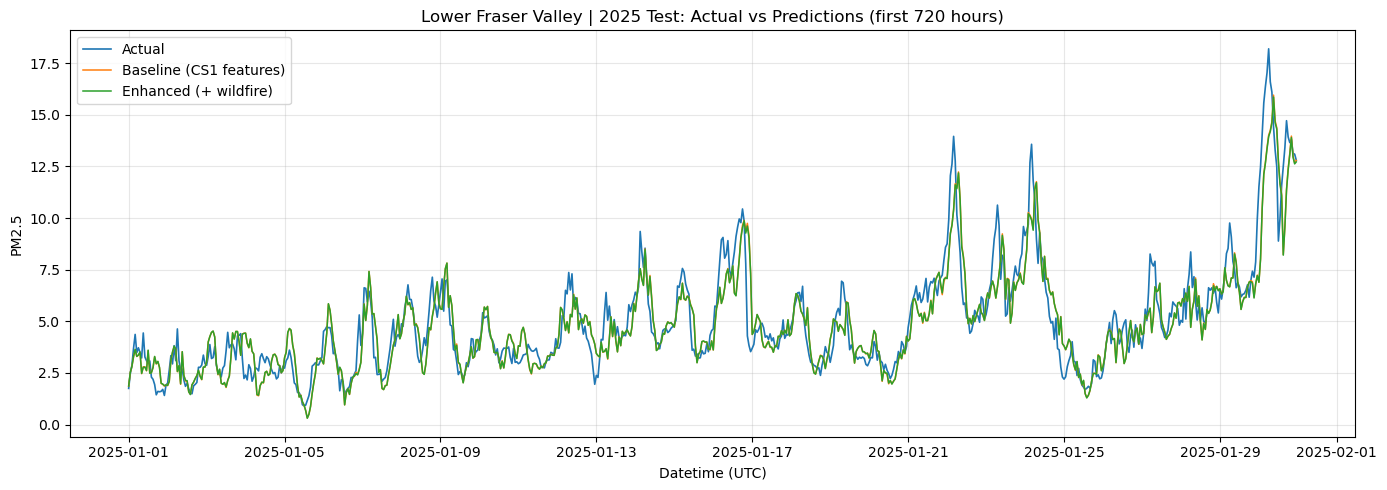

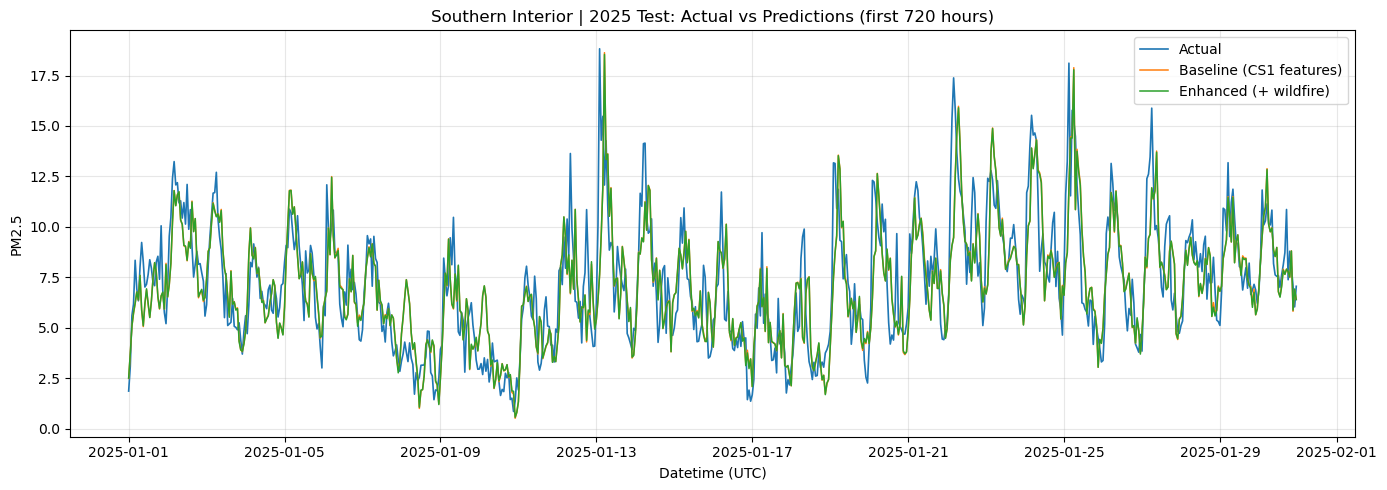

In [7]:
def plot_test_series(pred_base: pd.DataFrame, pred_enh: pd.DataFrame, zone: str, max_hours=24*21):
    # merge on datetime (inner join so both have same timestamps)
    a = pred_base.rename(columns={"y_pred": "y_pred_baseline"})[["Datetime_UTC", "y_true", "y_pred_baseline"]]
    b = pred_enh.rename(columns={"y_pred": "y_pred_enhanced"})[["Datetime_UTC", "y_pred_enhanced"]]
    m = a.merge(b, on="Datetime_UTC", how="inner").sort_values("Datetime_UTC")

    # optionally plot only first window for readability
    if max_hours is not None and len(m) > max_hours:
        m = m.iloc[:max_hours]

    plt.figure(figsize=(14, 5))
    plt.plot(m["Datetime_UTC"], m["y_true"], label="Actual", linewidth=1.2)
    plt.plot(m["Datetime_UTC"], m["y_pred_baseline"], label="Baseline (CS1 features)", linewidth=1.1)
    plt.plot(m["Datetime_UTC"], m["y_pred_enhanced"], label="Enhanced (+ wildfire)", linewidth=1.1)
    plt.title(f"{zone} | 2025 Test: Actual vs Predictions (first {len(m)} hours)")
    plt.xlabel("Datetime (UTC)")
    plt.ylabel("PM2.5")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

for z in zones:
    plot_test_series(preds_by_zone[z]["baseline"], preds_by_zone[z]["enhanced"], zone=z, max_hours=24*30)

In [8]:
# check wildfire season
THRESHOLD = 25.0

def filter_test_wildfire_season(d_model: pd.DataFrame, test_year=2025):
    d2 = d_model.copy()
    d2["year"] = d2["Datetime_UTC"].dt.year
    test = d2[d2["year"].eq(test_year)].copy()
    test_ws = test[test["is_wildfire_season"].eq(1)].copy()
    return test_ws

def eval_on_subset(gam, test_df: pd.DataFrame, feature_cols: list[str], threshold=25.0):
    X = test_df[feature_cols].values
    y = test_df["PM25"].values
    yhat = gam.predict(X)

    rmse = float(np.sqrt(mean_squared_error(y, yhat)))
    mae  = float(mean_absolute_error(y, yhat))
    r2   = float(r2_score(y, yhat))

    y_true_bin = (y > threshold).astype(int)
    y_pred_bin = (yhat > threshold).astype(int)

    prec = float(precision_score(y_true_bin, y_pred_bin, zero_division=0))
    rec  = float(recall_score(y_true_bin, y_pred_bin, zero_division=0))
    f1   = float(f1_score(y_true_bin, y_pred_bin, zero_division=0))

    return {
        "N_test_wildfire_season": int(len(test_df)),
        "RMSE_WS": rmse,
        "MAE_WS": mae,
        "R2_WS": r2,
        f"Precision@{threshold:g}_WS": prec,
        f"Recall@{threshold:g}_WS": rec,
        f"F1@{threshold:g}_WS": f1,
        "ActualEvents_WS": int(y_true_bin.sum()),
        "PredEvents_WS": int(y_pred_bin.sum()),
    }, pd.DataFrame({"Datetime_UTC": test_df["Datetime_UTC"].values,
                    "y_true": y,
                    "y_pred": yhat}).sort_values("Datetime_UTC")
zones = sorted(df["Zone"].unique())

all_rows_ws = []
preds_ws_by_zone = {}
models_by_zone = {}

for z in zones:
    dz = make_zone_table(df[df["Zone"] == z])

    # Fit on full 2022-2024 train (same as before)
    gam_base, m_base, p_base = fit_gam_and_eval(dz, BASE_COLS, threshold=THRESHOLD)
    gam_enh,  m_enh,  p_enh  = fit_gam_and_eval(dz, ENHANCED_COLS, threshold=THRESHOLD)

    models_by_zone[z] = {"baseline": gam_base, "enhanced": gam_enh}

    # Build the same modeling table used in training (dropna happens inside eval)
    d_model_base = dz.dropna(subset=BASE_COLS + ["PM25"]).copy()
    d_model_enh  = dz.dropna(subset=ENHANCED_COLS + ["PM25"]).copy()

    # Filter to 2025 wildfire season
    test_ws_base = filter_test_wildfire_season(d_model_base, test_year=2025)
    test_ws_enh  = filter_test_wildfire_season(d_model_enh,  test_year=2025)

    # Evaluate both models on wildfire season subset
    met_ws_base, pred_ws_base = eval_on_subset(gam_base, test_ws_base, BASE_COLS, threshold=THRESHOLD)
    met_ws_enh,  pred_ws_enh  = eval_on_subset(gam_enh,  test_ws_enh,  ENHANCED_COLS, threshold=THRESHOLD)

    all_rows_ws.append({"Zone": z, "Model": "Baseline_CS1Features_GAM", **met_ws_base})
    all_rows_ws.append({"Zone": z, "Model": "Enhanced_Wildfire_GAM", **met_ws_enh})

    preds_ws_by_zone[z] = {"baseline": pred_ws_base, "enhanced": pred_ws_enh}

metrics_ws_df = pd.DataFrame(all_rows_ws).sort_values(["Zone", "Model"]).reset_index(drop=True)
display(metrics_ws_df)


,Zone,Model,N_test_wildfire_season,RMSE_WS,MAE_WS,R2_WS,Precision@25_WS,Recall@25_WS,F1@25_WS,ActualEvents_WS,PredEvents_WS
0,Lower Fraser Valley,Baseline_CS1Features_GAM,4416,1.409304,0.745549,0.821102,0.500000,0.538462,0.518519,13,14
1,Lower Fraser Valley,Enhanced_Wildfire_GAM,4416,1.414979,0.755228,0.819659,0.500000,0.538462,0.518519,13,14
2,Southern Interior,Baseline_CS1Features_GAM,4416,1.800604,1.172958,0.910514,0.945455,0.896552,0.920354,116,110
3,Southern Interior,Enhanced_Wildfire_GAM,4416,1.833590,1.203466,0.907205,0.937500,0.905172,0.921053,116,112


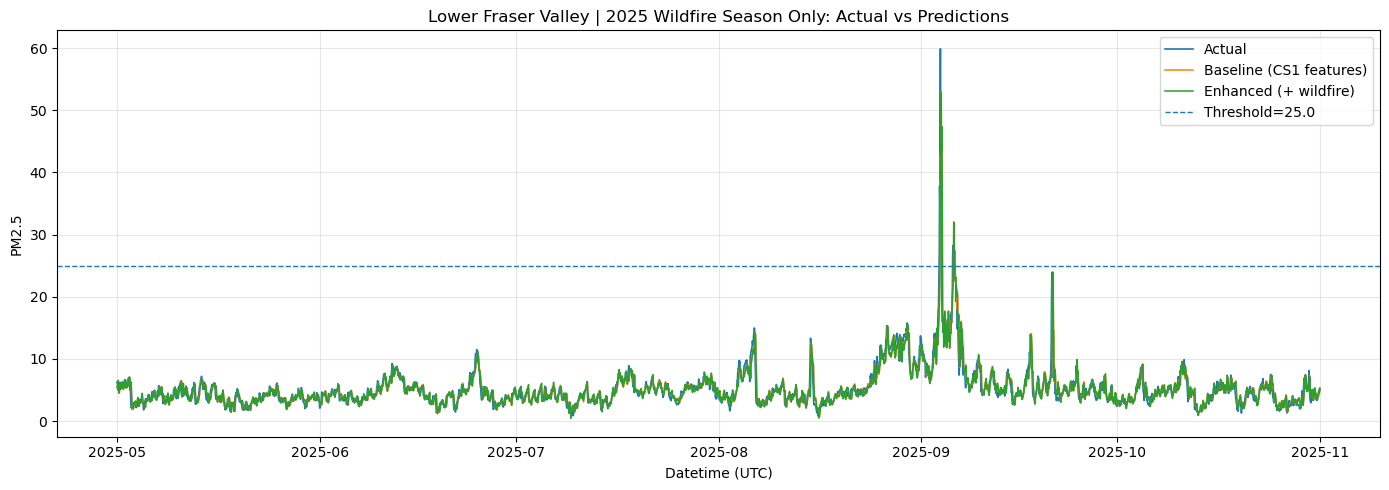

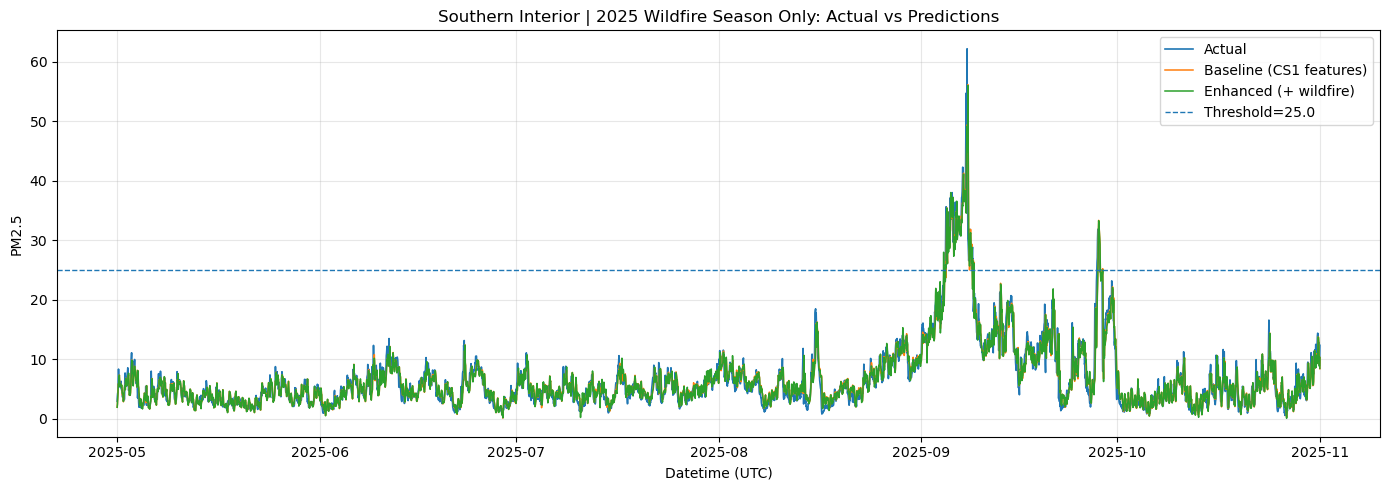

In [9]:
def plot_wildfire_season_series(pred_base: pd.DataFrame, pred_enh: pd.DataFrame, zone: str, threshold=25.0):
    a = pred_base.rename(columns={"y_pred": "y_pred_baseline"})[["Datetime_UTC", "y_true", "y_pred_baseline"]]
    b = pred_enh.rename(columns={"y_pred": "y_pred_enhanced"})[["Datetime_UTC", "y_pred_enhanced"]]
    m = a.merge(b, on="Datetime_UTC", how="inner").sort_values("Datetime_UTC")

    plt.figure(figsize=(14, 5))
    plt.plot(m["Datetime_UTC"], m["y_true"], label="Actual", linewidth=1.2)
    plt.plot(m["Datetime_UTC"], m["y_pred_baseline"], label="Baseline (CS1 features)", linewidth=1.1)
    plt.plot(m["Datetime_UTC"], m["y_pred_enhanced"], label="Enhanced (+ wildfire)", linewidth=1.1)
    plt.axhline(threshold, linestyle="--", linewidth=1, label=f"Threshold={threshold}")
    plt.title(f"{zone} | 2025 Wildfire Season Only: Actual vs Predictions")
    plt.xlabel("Datetime (UTC)")
    plt.ylabel("PM2.5")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

for z in zones:
    plot_wildfire_season_series(
        preds_ws_by_zone[z]["baseline"],
        preds_ws_by_zone[z]["enhanced"],
        zone=z,
        threshold=THRESHOLD
    )

## CNN for feature extraction

In [ ]:
# CNN feature extractor -> GAM
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

CNN_WINDOW = 72
CNN_EMBED_DIM = 8
CNN_BATCH_SIZE = 256
CNN_EPOCHS = 25
CNN_LEARNING_RATE = 1e-3
CNN_WEIGHT_DECAY = 1e-4
CNN_PATIENCE = 6
CNN_THRESHOLD = THRESHOLD
CNN_VALID_FRACTION = 0.15
CNN_SEED = 42
CNN_DROPOUT = 0.20
OPTUNA_TRIALS = 8
OPTUNA_TIMEOUT = 600


def set_torch_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class SequenceDataset(Dataset):
    def __init__(self, X_seq: np.ndarray, y: np.ndarray):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.y[idx]


class ResidualConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout_rate: float):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.proj = None
        if in_channels != out_channels:
            self.proj = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self, x):
        identity = x if self.proj is None else self.proj(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + identity
        out = self.relu(out)
        return self.dropout(out)


class PM25CNNRegressor(nn.Module):
    def __init__(self, in_channels: int, embed_dim: int = 8, dropout_rate: float = 0.20):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )
        self.res_stack = nn.Sequential(
            ResidualConvBlock(32, 32, dropout_rate=dropout_rate),
            ResidualConvBlock(32, 64, dropout_rate=dropout_rate),
            ResidualConvBlock(64, 64, dropout_rate=dropout_rate),
        )
        self.feature_extractor = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, embed_dim),
            nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(embed_dim, 1),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.stem(x)
        x = self.res_stack(x)
        features = self.feature_extractor(x)
        return self.head(features).squeeze(-1)

    def extract_features(self, x):
        x = x.transpose(1, 2)
        x = self.stem(x)
        x = self.res_stack(x)
        return self.feature_extractor(x)


def build_sequences_from_table(
    d: pd.DataFrame,
    feature_cols: list[str],
    scaler: StandardScaler,
    window_size: int,
    years,
):
    subset = d[d["Datetime_UTC"].dt.year.isin(years)].copy()
    subset = subset.dropna(subset=feature_cols + ["PM25"]).sort_values("Datetime_UTC").reset_index(drop=True)

    if len(subset) <= window_size:
        raise ValueError(f"Not enough rows to build sequences for years={years}: n={len(subset)}")

    scaled_values = scaler.transform(subset[feature_cols])
    y_values = subset["PM25"].to_numpy(dtype=np.float32)
    dt_values = subset["Datetime_UTC"].to_numpy()

    X_seq = []
    y_seq = []
    dt_seq = []
    for end_idx in range(window_size - 1, len(subset)):
        start_idx = end_idx - window_size + 1
        X_seq.append(scaled_values[start_idx : end_idx + 1])
        y_seq.append(y_values[end_idx])
        dt_seq.append(dt_values[end_idx])

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
        np.asarray(dt_seq),
    )


def split_sequence_data(
    X_seq: np.ndarray,
    y_seq: np.ndarray,
    dt_seq: np.ndarray,
    valid_fraction: float = 0.15,
):
    split_idx = max(1, int(len(X_seq) * (1 - valid_fraction)))
    split_idx = min(split_idx, len(X_seq) - 1)

    return {
        "X_fit": X_seq[:split_idx],
        "y_fit": y_seq[:split_idx],
        "dt_fit": dt_seq[:split_idx],
        "X_valid": X_seq[split_idx:],
        "y_valid": y_seq[split_idx:],
        "dt_valid": dt_seq[split_idx:],
    }


def make_cnn_loaders(
    X_fit: np.ndarray,
    y_fit: np.ndarray,
    X_valid: np.ndarray,
    y_valid: np.ndarray,
    batch_size: int,
):
    train_loader = DataLoader(
        SequenceDataset(X_fit, y_fit),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )
    valid_loader = DataLoader(
        SequenceDataset(X_valid, y_valid),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )
    return train_loader, valid_loader


def evaluate_cnn(model: nn.Module, loader: DataLoader, device: torch.device):
    criterion = nn.MSELoss()
    model.eval()
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * len(X_batch)
            total_count += len(X_batch)

    return total_loss / max(total_count, 1)


def train_cnn_regressor(
    X_train: np.ndarray,
    y_train: np.ndarray,
    embed_dim: int = 8,
    epochs: int = 25,
    batch_size: int = 256,
    learning_rate: float = 1e-3,
    weight_decay: float = 1e-4,
    patience: int = 6,
    valid_fraction: float = 0.15,
    seed: int = 42,
    dropout_rate: float = 0.20,
    X_valid: np.ndarray | None = None,
    y_valid: np.ndarray | None = None,
):
    set_torch_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PM25CNNRegressor(
        in_channels=X_train.shape[-1],
        embed_dim=embed_dim,
        dropout_rate=dropout_rate,
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    if X_valid is None or y_valid is None:
        split_data = split_sequence_data(
            X_train,
            y_train,
            np.arange(len(X_train)),
            valid_fraction=valid_fraction,
        )
        X_fit = split_data["X_fit"]
        y_fit = split_data["y_fit"]
        X_valid_local = split_data["X_valid"]
        y_valid_local = split_data["y_valid"]
    else:
        X_fit = X_train
        y_fit = y_train
        X_valid_local = X_valid
        y_valid_local = y_valid

    train_loader, valid_loader = make_cnn_loaders(
        X_fit,
        y_fit,
        X_valid_local,
        y_valid_local,
        batch_size=batch_size,
    )

    best_state = None
    best_valid_loss = np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_count = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(X_batch)
            running_count += len(X_batch)

        train_loss = running_loss / max(running_count, 1)
        valid_loss = evaluate_cnn(model, valid_loader, device)
        history.append({"epoch": epoch + 1, "train_loss": train_loss, "valid_loss": valid_loss})

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def predict_cnn(model: nn.Module, X_seq: np.ndarray):
    device = next(model.parameters()).device
    loader = DataLoader(
        SequenceDataset(X_seq, np.zeros(len(X_seq), dtype=np.float32)),
        batch_size=CNN_BATCH_SIZE,
        shuffle=False,
    )
    preds = []

    model.eval()
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            batch_preds = model(X_batch).detach().cpu().numpy()
            preds.append(batch_preds)

    return np.concatenate(preds, axis=0)


def extract_cnn_features(model: nn.Module, X_seq: np.ndarray, dt_values: np.ndarray, y_values: np.ndarray):
    device = next(model.parameters()).device
    loader = DataLoader(SequenceDataset(X_seq, y_values), batch_size=CNN_BATCH_SIZE, shuffle=False)
    feature_batches = []

    model.eval()
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            batch_features = model.extract_features(X_batch).detach().cpu().numpy()
            feature_batches.append(batch_features)

    features = np.vstack(feature_batches)
    feature_cols = [f"cnn_feat_{i + 1}" for i in range(features.shape[1])]
    feat_df = pd.DataFrame(features, columns=feature_cols)
    feat_df.insert(0, "Datetime_UTC", dt_values)
    feat_df["PM25"] = y_values
    return feat_df, feature_cols


def compute_gam_rmse(
    train_feat_df: pd.DataFrame,
    valid_feat_df: pd.DataFrame,
    feature_cols: list[str],
):
    X_train = train_feat_df[feature_cols].to_numpy()
    y_train = train_feat_df["PM25"].to_numpy()
    X_valid = valid_feat_df[feature_cols].to_numpy()
    y_valid = valid_feat_df["PM25"].to_numpy()

    terms = None
    for idx in range(len(feature_cols)):
        terms = s(idx) if terms is None else terms + s(idx)

    gam = LinearGAM(terms).fit(X_train, y_train)
    y_pred = gam.predict(X_valid)
    return float(np.sqrt(mean_squared_error(y_valid, y_pred)))


def tune_cnn_feature_extractor(
    X_train_seq: np.ndarray,
    y_train_seq: np.ndarray,
    dt_train_seq: np.ndarray,
    n_trials: int = 8,
    timeout: int = 600,
    seed: int = 42,
):
    split_data = split_sequence_data(
        X_train_seq,
        y_train_seq,
        dt_train_seq,
        valid_fraction=CNN_VALID_FRACTION,
    )

    def objective(trial: optuna.Trial):
        trial_params = {
            "embed_dim": trial.suggest_categorical("embed_dim", [8, 16, 24, 32]),
            "dropout_rate": trial.suggest_float("dropout_rate", 0.10, 0.40),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [128, 256]),
            "epochs": trial.suggest_categorical("epochs", [10, 15, 20]),
        }

        model, history_df = train_cnn_regressor(
            split_data["X_fit"],
            split_data["y_fit"],
            embed_dim=trial_params["embed_dim"],
            epochs=trial_params["epochs"],
            batch_size=trial_params["batch_size"],
            learning_rate=trial_params["learning_rate"],
            weight_decay=trial_params["weight_decay"],
            patience=CNN_PATIENCE,
            valid_fraction=CNN_VALID_FRACTION,
            seed=seed,
            dropout_rate=trial_params["dropout_rate"],
            X_valid=split_data["X_valid"],
            y_valid=split_data["y_valid"],
        )

        fit_feat_df, feature_cols = extract_cnn_features(
            model,
            split_data["X_fit"],
            split_data["dt_fit"],
            split_data["y_fit"],
        )
        valid_feat_df, _ = extract_cnn_features(
            model,
            split_data["X_valid"],
            split_data["dt_valid"],
            split_data["y_valid"],
        )

        valid_rmse = compute_gam_rmse(fit_feat_df, valid_feat_df, feature_cols)
        trial.set_user_attr("gam_validation_rmse", valid_rmse)
        trial.set_user_attr("epochs_trained", int(len(history_df)))
        return valid_rmse

    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=False)

    trial_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))
    return study.best_params, study, trial_df


def fit_gam_on_feature_table(
    train_feat_df: pd.DataFrame,
    test_feat_df: pd.DataFrame,
    feature_cols: list[str],
    threshold: float = 25.0,
):
    X_train = train_feat_df[feature_cols].to_numpy()
    y_train = train_feat_df["PM25"].to_numpy()
    X_test = test_feat_df[feature_cols].to_numpy()
    y_test = test_feat_df["PM25"].to_numpy()

    terms = None
    for idx in range(len(feature_cols)):
        terms = s(idx) if terms is None else terms + s(idx)

    gam = LinearGAM(terms).fit(X_train, y_train)
    y_pred = gam.predict(X_test)

    y_true_bin = (y_test > threshold).astype(int)
    y_pred_bin = (y_pred > threshold).astype(int)

    metrics = {
        "N_train": int(len(train_feat_df)),
        "N_test": int(len(test_feat_df)),
        "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "MAE": float(mean_absolute_error(y_test, y_pred)),
        "R2": float(r2_score(y_test, y_pred)),
        f"Precision@{threshold:g}": float(precision_score(y_true_bin, y_pred_bin, zero_division=0)),
        f"Recall@{threshold:g}": float(recall_score(y_true_bin, y_pred_bin, zero_division=0)),
        f"F1@{threshold:g}": float(f1_score(y_true_bin, y_pred_bin, zero_division=0)),
        "ActualEvents": int(y_true_bin.sum()),
        "PredEvents": int(y_pred_bin.sum()),
        "GAM_PseudoR2_ExplDev": float(gam.statistics_["pseudo_r2"]["explained_deviance"]),
    }

    pred_df = pd.DataFrame(
        {
            "Datetime_UTC": test_feat_df["Datetime_UTC"].to_numpy(),
            "y_true": y_test,
            "y_pred": y_pred,
        }
    ).sort_values("Datetime_UTC")

    return gam, metrics, pred_df

In [33]:
cnn_metrics_rows = []
cnn_training_history = {}
cnn_preds_by_zone = {}
cnn_feature_tables = {}
cnn_models_by_zone = {}
cnn_gams_by_zone = {}
cnn_optuna_by_zone = {}
cnn_tuning_rows = []

baseline2_metrics = metrics_df[metrics_df["Model"].eq("Enhanced_Wildfire_GAM")].copy()

for z in zones:
    dz = make_zone_table(df[df["Zone"] == z])
    d_model = dz.dropna(subset=ENHANCED_COLS + ["PM25"]).copy()
    train_rows = d_model[d_model["Datetime_UTC"].dt.year.isin([2022, 2023, 2024])].copy()

    if len(train_rows) <= CNN_WINDOW:
        raise ValueError(f"Zone {z} does not have enough training rows for window={CNN_WINDOW}")

    scaler = StandardScaler().fit(train_rows[ENHANCED_COLS])

    X_train_seq, y_train_seq, dt_train_seq = build_sequences_from_table(
        d_model,
        ENHANCED_COLS,
        scaler,
        window_size=CNN_WINDOW,
        years=[2022, 2023, 2024],
    )
    X_test_seq, y_test_seq, dt_test_seq = build_sequences_from_table(
        d_model,
        ENHANCED_COLS,
        scaler,
        window_size=CNN_WINDOW,
        years=[2025],
    )

    best_params, study, trial_df = tune_cnn_feature_extractor(
        X_train_seq,
        y_train_seq,
        dt_train_seq,
        n_trials=OPTUNA_TRIALS,
        timeout=OPTUNA_TIMEOUT,
        seed=CNN_SEED,
    )

    cnn_optuna_by_zone[z] = {
        "study": study,
        "trials": trial_df,
        "best_params": best_params,
    }
    cnn_tuning_rows.append(
        {
            "Zone": z,
            "Validation_RMSE": float(study.best_value),
            **{f"best_{k}": v for k, v in best_params.items()},
        }
    )

    cnn_model, history_df = train_cnn_regressor(
        X_train_seq,
        y_train_seq,
        embed_dim=int(best_params["embed_dim"]),
        epochs=int(best_params["epochs"]),
        batch_size=int(best_params["batch_size"]),
        learning_rate=float(best_params["learning_rate"]),
        weight_decay=float(best_params["weight_decay"]),
        patience=CNN_PATIENCE,
        valid_fraction=CNN_VALID_FRACTION,
        seed=CNN_SEED,
        dropout_rate=float(best_params["dropout_rate"]),
    )

    train_feat_df, cnn_feature_cols = extract_cnn_features(cnn_model, X_train_seq, dt_train_seq, y_train_seq)
    test_feat_df, _ = extract_cnn_features(cnn_model, X_test_seq, dt_test_seq, y_test_seq)

    cnn_direct_pred = predict_cnn(cnn_model, X_test_seq)
    cnn_direct_metrics = {
        "Zone": z,
        "Model": "CNN_Direct",
        "N_train": int(len(X_train_seq)),
        "N_test": int(len(X_test_seq)),
        "RMSE": float(np.sqrt(mean_squared_error(y_test_seq, cnn_direct_pred))),
        "MAE": float(mean_absolute_error(y_test_seq, cnn_direct_pred)),
        "R2": float(r2_score(y_test_seq, cnn_direct_pred)),
        f"Precision@{CNN_THRESHOLD:g}": float(precision_score((y_test_seq > CNN_THRESHOLD).astype(int), (cnn_direct_pred > CNN_THRESHOLD).astype(int), zero_division=0)),
        f"Recall@{CNN_THRESHOLD:g}": float(recall_score((y_test_seq > CNN_THRESHOLD).astype(int), (cnn_direct_pred > CNN_THRESHOLD).astype(int), zero_division=0)),
        f"F1@{CNN_THRESHOLD:g}": float(f1_score((y_test_seq > CNN_THRESHOLD).astype(int), (cnn_direct_pred > CNN_THRESHOLD).astype(int), zero_division=0)),
        "ActualEvents": int((y_test_seq > CNN_THRESHOLD).sum()),
        "PredEvents": int((cnn_direct_pred > CNN_THRESHOLD).sum()),
        "GAM_PseudoR2_ExplDev": np.nan,
    }

    cnn_gam, cnn_gam_metrics, cnn_gam_pred_df = fit_gam_on_feature_table(
        train_feat_df,
        test_feat_df,
        feature_cols=cnn_feature_cols,
        threshold=CNN_THRESHOLD,
    )
    cnn_gam_metrics = {"Zone": z, "Model": "CNN_FeatureExtractor_GAM", **cnn_gam_metrics}

    cnn_metrics_rows.extend([cnn_direct_metrics, cnn_gam_metrics])
    cnn_training_history[z] = history_df
    cnn_models_by_zone[z] = cnn_model
    cnn_gams_by_zone[z] = cnn_gam
    cnn_feature_tables[z] = {"train": train_feat_df, "test": test_feat_df}
    cnn_preds_by_zone[z] = {
        "cnn_direct": pd.DataFrame(
            {"Datetime_UTC": dt_test_seq, "y_true": y_test_seq, "y_pred": cnn_direct_pred}
        ).sort_values("Datetime_UTC"),
        "cnn_gam": cnn_gam_pred_df,
        "baseline2": preds_by_zone[z]["enhanced"].copy(),
    }

cnn_tuning_df = pd.DataFrame(cnn_tuning_rows).sort_values("Zone").reset_index(drop=True)
display(cnn_tuning_df)

cnn_metrics_df = pd.DataFrame(cnn_metrics_rows).sort_values(["Zone", "Model"]).reset_index(drop=True)
display(cnn_metrics_df)

comparison_df = baseline2_metrics.merge(
    cnn_metrics_df[cnn_metrics_df["Model"].eq("CNN_FeatureExtractor_GAM")],
    on="Zone",
    how="inner",
    suffixes=("_Baseline2", "_CNNGAM"),
)

display(comparison_df)

,Zone,Validation_RMSE,best_embed_dim,best_dropout_rate,best_learning_rate,best_weight_decay,best_batch_size,best_epochs
0,Lower Fraser Valley,1.385483,24,0.184280,0.000836,0.000003,128,10
1,Southern Interior,2.785278,24,0.136611,0.000694,0.000001,128,10


,Zone,Model,N_train,N_test,RMSE,MAE,R2,Precision@25,Recall@25,F1@25,ActualEvents,PredEvents,GAM_PseudoR2_ExplDev
0,Lower Fraser Valley,CNN_Direct,26176,8689,1.641829,0.994959,0.655696,1.00,0.076923,0.142857,13,1,NaN
1,Lower Fraser Valley,CNN_FeatureExtractor_GAM,26176,8689,1.548922,0.944699,0.693560,0.75,0.230769,0.352941,13,4,0.888067
2,Southern Interior,CNN_Direct,26176,8689,3.196512,2.041928,0.569447,1.00,0.034483,0.066667,116,4,NaN
3,Southern Interior,CNN_FeatureExtractor_GAM,26176,8689,2.761213,1.871477,0.678727,1.00,0.336207,0.503226,116,39,0.891686


,Zone,Model_Baseline2,N_train_Baseline2,N_test_Baseline2,RMSE_Baseline2,MAE_Baseline2,R2_Baseline2,Precision@25_Baseline2,Recall@25_Baseline2,F1@25_Baseline2,...,N_test_CNNGAM,RMSE_CNNGAM,MAE_CNNGAM,R2_CNNGAM,Precision@25_CNNGAM,Recall@25_CNNGAM,F1@25_CNNGAM,ActualEvents_CNNGAM,PredEvents_CNNGAM,GAM_PseudoR2_ExplDev_CNNGAM
0,Lower Fraser Valley,Enhanced_Wildfire_GAM,26247,8760,1.190489,0.714290,0.818152,0.5000,0.538462,0.518519,...,8689,1.548922,0.944699,0.693560,0.75,0.230769,0.352941,13,4,0.888067
1,Southern Interior,Enhanced_Wildfire_GAM,26247,8760,1.827264,1.270637,0.858633,0.9375,0.905172,0.921053,...,8689,2.761213,1.871477,0.678727,1.00,0.336207,0.503226,116,39,0.891686


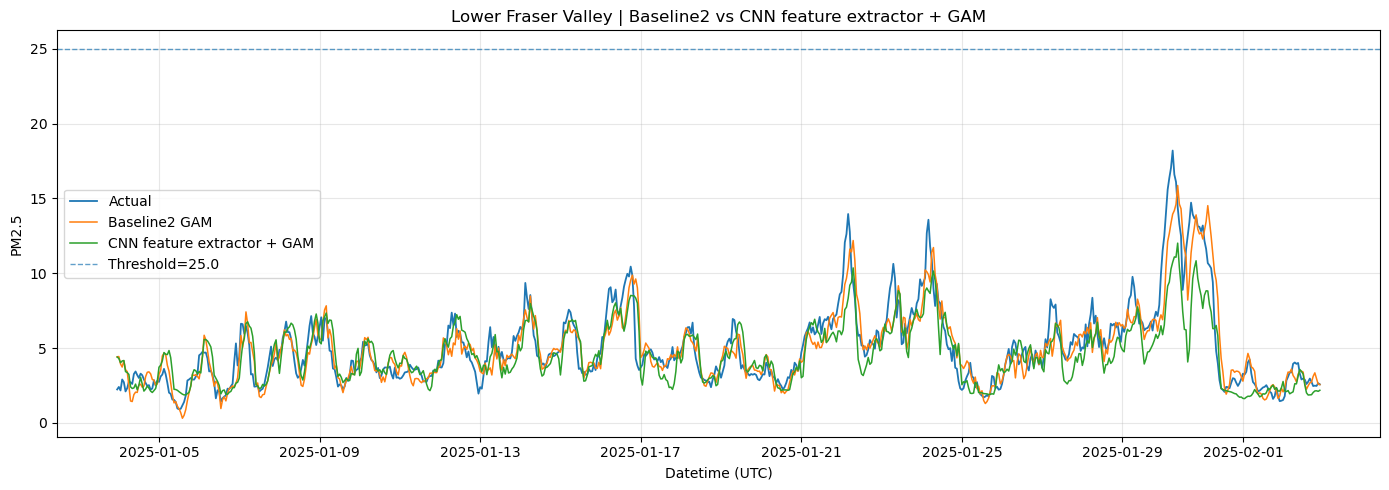

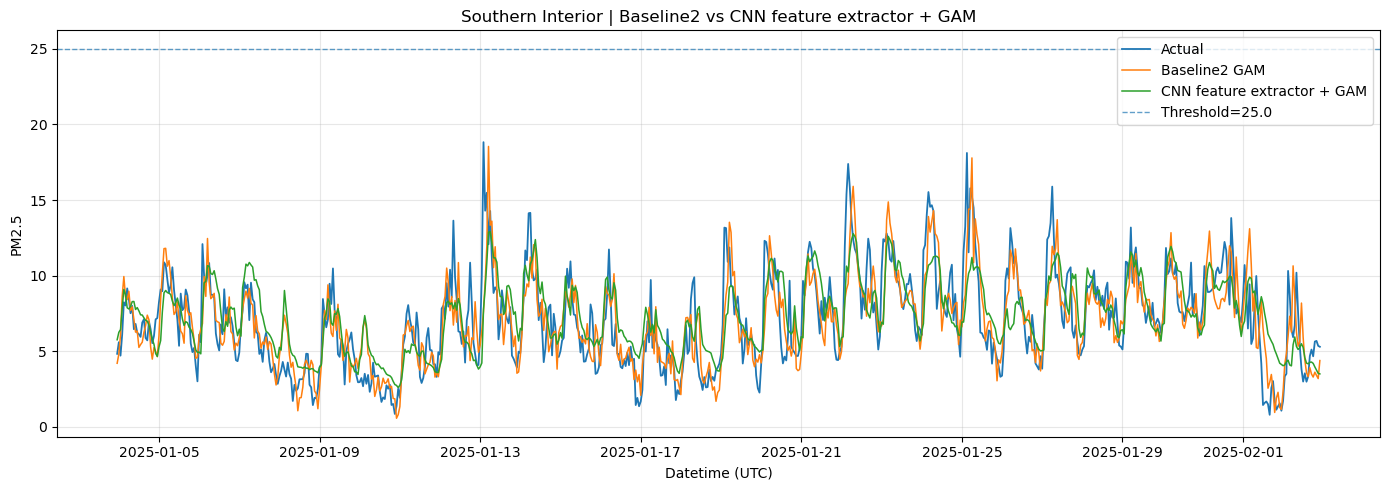

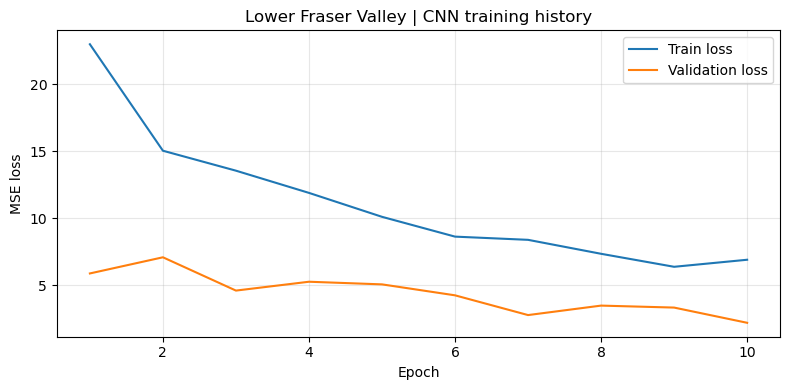

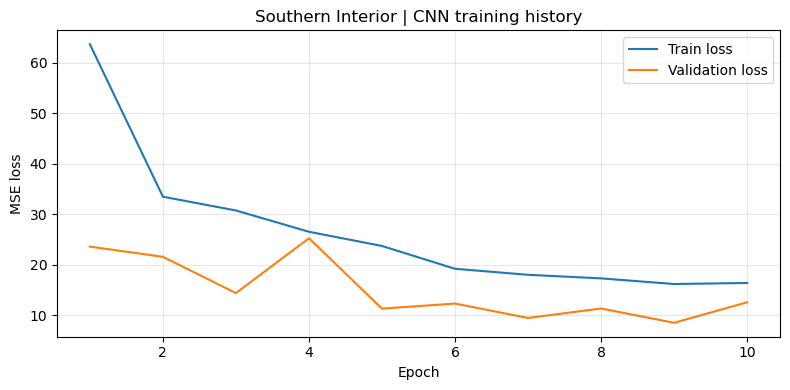

In [34]:
def plot_cnn_vs_baseline(pred_baseline: pd.DataFrame, pred_cnn_gam: pd.DataFrame, zone: str, max_hours=24 * 30):
    baseline = pred_baseline.rename(columns={"y_pred": "y_pred_baseline"})[["Datetime_UTC", "y_true", "y_pred_baseline"]].copy()
    cnn_gam = pred_cnn_gam.rename(columns={"y_pred": "y_pred_cnn_gam"})[["Datetime_UTC", "y_pred_cnn_gam"]].copy()

    baseline["Datetime_UTC"] = pd.to_datetime(baseline["Datetime_UTC"], utc=True)
    cnn_gam["Datetime_UTC"] = pd.to_datetime(cnn_gam["Datetime_UTC"], utc=True)

    merged = baseline.merge(cnn_gam, on="Datetime_UTC", how="inner").sort_values("Datetime_UTC")

    if max_hours is not None and len(merged) > max_hours:
        merged = merged.iloc[:max_hours]

    plt.figure(figsize=(14, 5))
    plt.plot(merged["Datetime_UTC"], merged["y_true"], label="Actual", linewidth=1.3)
    plt.plot(merged["Datetime_UTC"], merged["y_pred_baseline"], label="Baseline2 GAM", linewidth=1.1)
    plt.plot(merged["Datetime_UTC"], merged["y_pred_cnn_gam"], label="CNN feature extractor + GAM", linewidth=1.1)
    plt.axhline(CNN_THRESHOLD, linestyle="--", linewidth=1, alpha=0.7, label=f"Threshold={CNN_THRESHOLD}")
    plt.title(f"{zone} | Baseline2 vs CNN feature extractor + GAM")
    plt.xlabel("Datetime (UTC)")
    plt.ylabel("PM2.5")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


for z in zones:
    plot_cnn_vs_baseline(
        cnn_preds_by_zone[z]["baseline2"],
        cnn_preds_by_zone[z]["cnn_gam"],
        zone=z,
        max_hours=24 * 30,
    )


for z in zones:
    history_df = cnn_training_history[z]
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation loss")
    plt.title(f"{z} | CNN training history")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()